# **Assigment 1: Unsupervised Learning Methods**

## **Dataset**

In [1]:
%pip install ucimlrepo

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables) 


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

## **Task 1**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import math
import seaborn as sns
from sklearn.impute import SimpleImputer

In [4]:
print(X.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  


In [5]:
print(y.head())

   num
0    0
1    2
2    1
3    0
4    0


### Load the dataset and display its shape, data types, and summary statistics

In [6]:
# Shape
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (303, 13)
y shape: (303, 1)


In [7]:
# Data types
print("\nData types features:")
print(X.dtypes)
print("\nData types target:")
print(y.dtypes)


Data types features:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object

Data types target:
num    int64
dtype: object


In [8]:
# Summary statistics
print("\nSummary statistics:")
print(X.describe(include="all").T)
print("\nTarget distribution:")
print(y.value_counts())


Summary statistics:
          count        mean        std    min    25%    50%    75%    max
age       303.0   54.438944   9.038662   29.0   48.0   56.0   61.0   77.0
sex       303.0    0.679868   0.467299    0.0    0.0    1.0    1.0    1.0
cp        303.0    3.158416   0.960126    1.0    3.0    3.0    4.0    4.0
trestbps  303.0  131.689769  17.599748   94.0  120.0  130.0  140.0  200.0
chol      303.0  246.693069  51.776918  126.0  211.0  241.0  275.0  564.0
fbs       303.0    0.148515   0.356198    0.0    0.0    0.0    0.0    1.0
restecg   303.0    0.990099   0.994971    0.0    0.0    1.0    2.0    2.0
thalach   303.0  149.607261  22.875003   71.0  133.5  153.0  166.0  202.0
exang     303.0    0.326733   0.469794    0.0    0.0    0.0    1.0    1.0
oldpeak   303.0    1.039604   1.161075    0.0    0.0    0.8    1.6    6.2
slope     303.0    1.600660   0.616226    1.0    1.0    2.0    2.0    3.0
ca        299.0    0.672241   0.937438    0.0    0.0    0.0    1.0    3.0
thal      301.0  

### Features Missing Values

In [9]:
# We report the missing values in the features of X, if any
missing_count = X.isna().sum()
missing_pct = (missing_count / len(X) * 100).round(2)

missing_report = (
    pd.DataFrame({
        "missing_count": missing_count,
        "missing_pct": missing_pct
    })
    .sort_values("missing_pct", ascending=False)
)

print("Features with missing values:")
print(missing_report if not missing_report.empty else "No missing values in X")

Features with missing values:
          missing_count  missing_pct
ca                    4         1.32
thal                  2         0.66
cp                    0         0.00
sex                   0         0.00
age                   0         0.00
chol                  0         0.00
trestbps              0         0.00
fbs                   0         0.00
restecg               0         0.00
exang                 0         0.00
thalach               0         0.00
slope                 0         0.00
oldpeak               0         0.00


As we can observe in the table, we only have missing data for the features ca - Major vessels (4 missing, 1.32%), and thal (2 missing, 0.66%). However, we must properly handle these missing values because PCA and clustering do not accept NaNs.

Although missingness is very small compared to the size of the dataset (303), and we could use a "dropping missing values" strategy, ca and thal are discrete variables, so we can try most-frequent imputation. This strategy keeps all 303 patients, which is important if we can avoid deleting patients in small datasets.

In [10]:
# Cleaned dataset with imputed values for missing data
X_clean = X.copy()

cat_missing_cols = ["ca", "thal"]
imputer = SimpleImputer(strategy="most_frequent")
X_clean[cat_missing_cols] = imputer.fit_transform(X_clean[cat_missing_cols])

print(X_clean.isna().sum())
print(X_clean.shape)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64
(303, 13)


## Plotting distributions of all features

Categorical variables: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Continuous variables: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


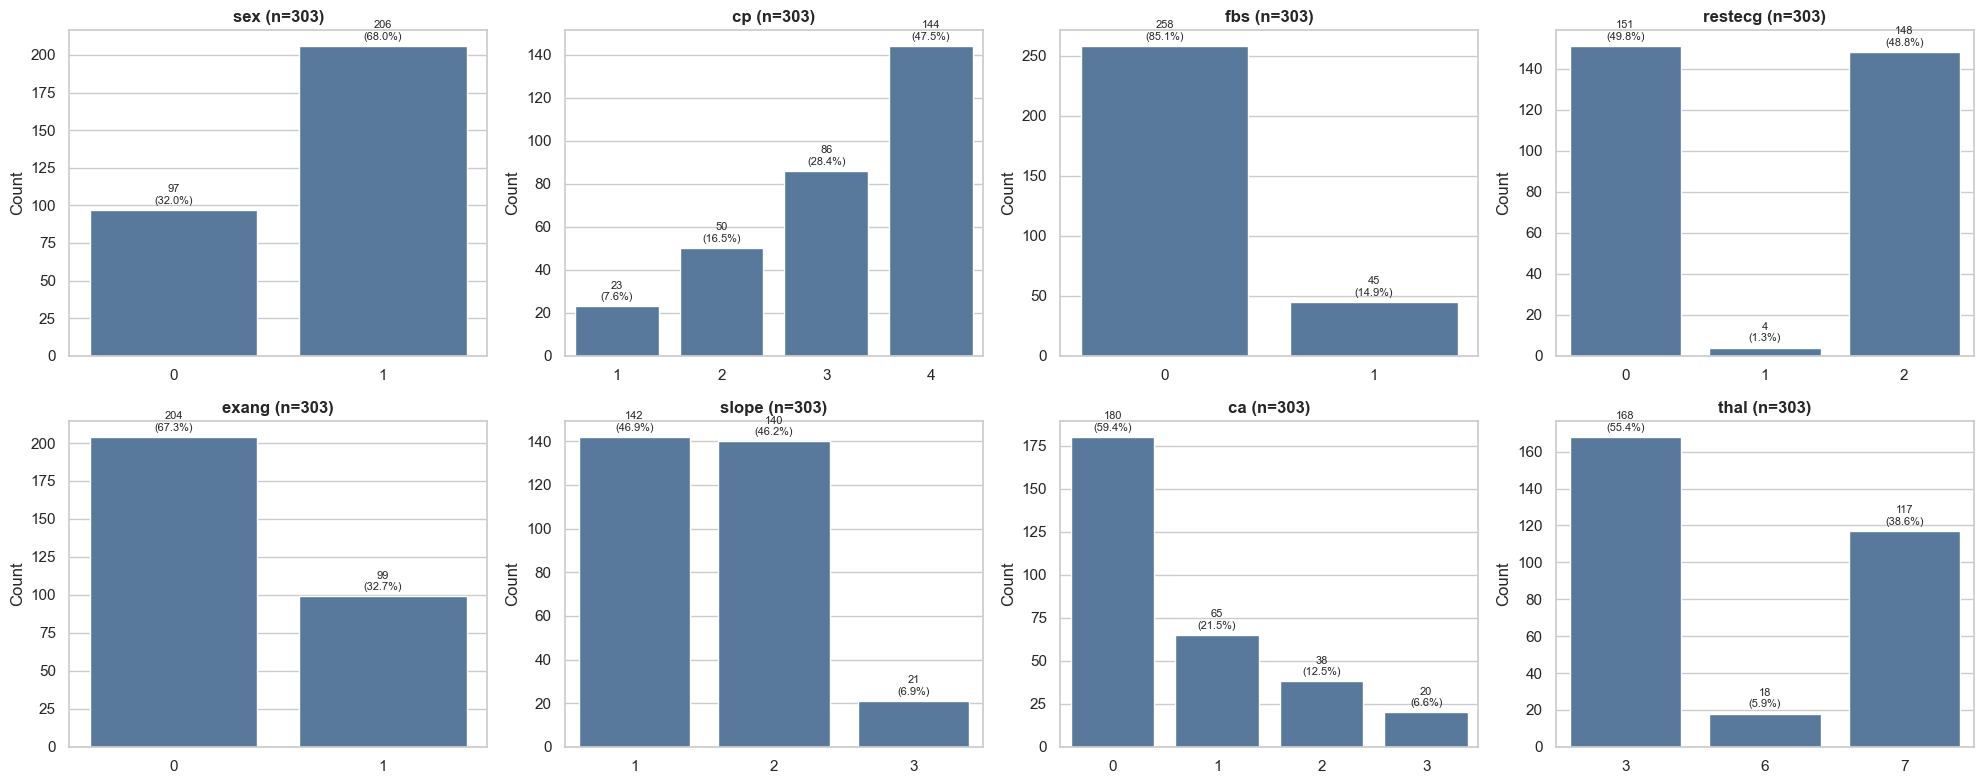

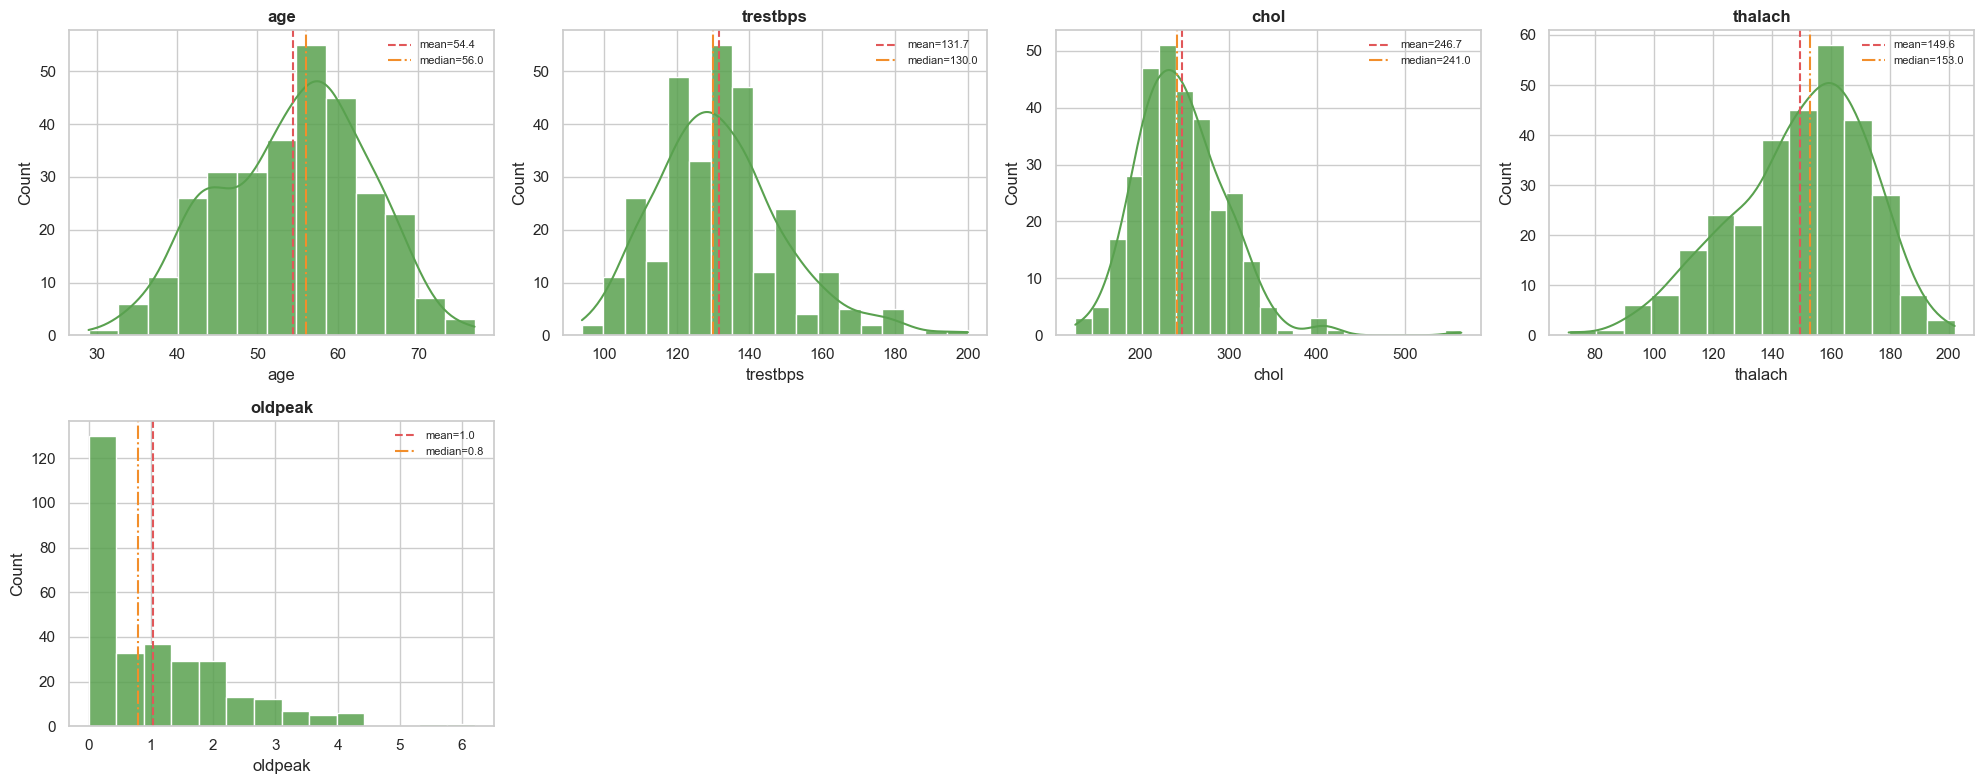

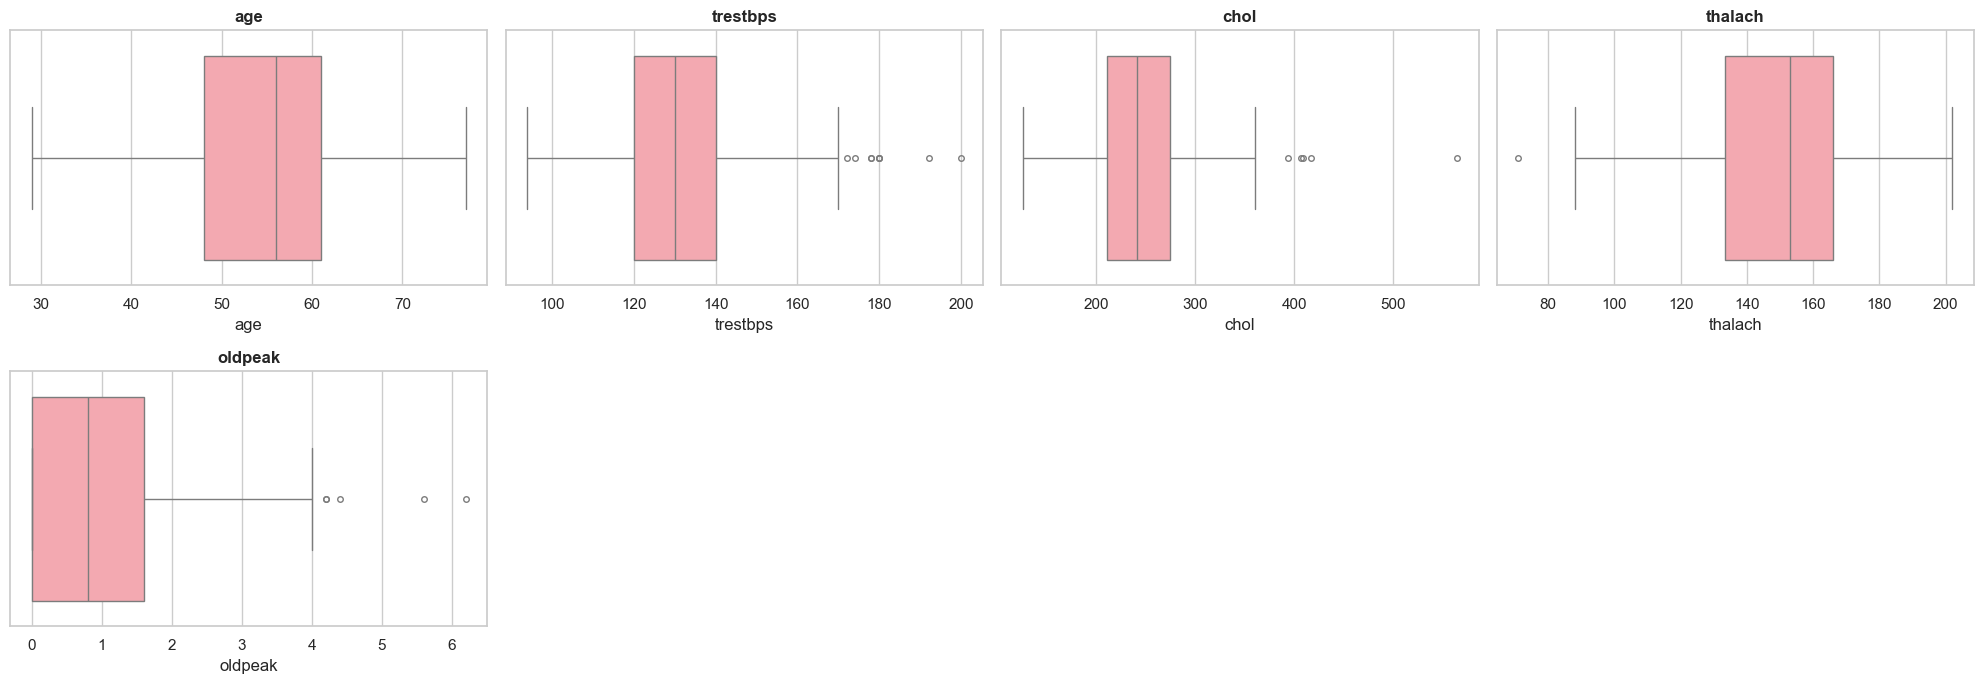

In [11]:
data = X_clean.copy()

# We identify the categorical and continuous variables based on the dataset
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
continuous_cols = [c for c in data.columns if c not in categorical_cols]

print("Categorical variables:", categorical_cols)
print("Continuous variables:", continuous_cols)

# Keep integrity of the categorical variables (ca/thal could be read as continuous but they are categorical)
for c in categorical_cols:
    data[c] = pd.to_numeric(data[c], errors="coerce").round().astype("Int64")

sns.set_theme(style="whitegrid", context="notebook")

# 1) For the categorical variables, we create count plots
n_cols = 4
n_rows = math.ceil(len(categorical_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    order = sorted(data[col].dropna().unique().tolist())
    sns.countplot(x=col, data=data, order=order, ax=ax, color="#4C78A8")

    total = data[col].notna().sum()
    for p in ax.patches:
        h = int(p.get_height())
        ax.annotate(f"{h}\n({h/total:.1%})",
                    (p.get_x() + p.get_width()/2, h),
                    ha="center", va="bottom", fontsize=8,
                    xytext=(0, 3), textcoords="offset points")

    ax.set_title(f"{col} (n={total})", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")


for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# 2) Continuous: histogram + KDE
n_rows = math.ceil(len(continuous_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(continuous_cols):
    ax = axes[i]
    use_kde = col != "oldpeak"  # oldpeak suele quedar mejor sin KDE
    sns.histplot(data[col], bins="fd", kde=use_kde, ax=ax,
                 color="#59A14F", edgecolor="white", alpha=0.85)

    mean_val = data[col].mean()
    med_val = data[col].median()
    ax.axvline(mean_val, color="#E15759", linestyle="--", linewidth=1.5, label=f"mean={mean_val:.1f}")
    ax.axvline(med_val, color="#F28E2B", linestyle="-.", linewidth=1.5, label=f"median={med_val:.1f}")

    ax.set_title(f"{col}", fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend(frameon=False, fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# 3) Continuous: Boxplot
n_rows = math.ceil(len(continuous_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.5*n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(continuous_cols):
    ax = axes[i]
    sns.boxplot(x=data[col], ax=ax, color="#FF9DA7", fliersize=4, linewidth=1)
    ax.set_title(f"{col}", fontweight="bold")
    ax.set_xlabel(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

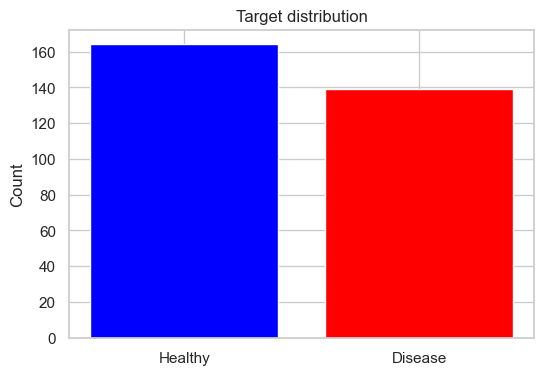

In [12]:
t = (y["num"] > 0).astype(int)   # 0 = healthy, 1 = disease
counts = t.value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(["Healthy", "Disease"], counts.values, color=["blue", "red"])
plt.ylabel("Count")
plt.title("Target distribution")
plt.show()

## Plotting correlation heatmap

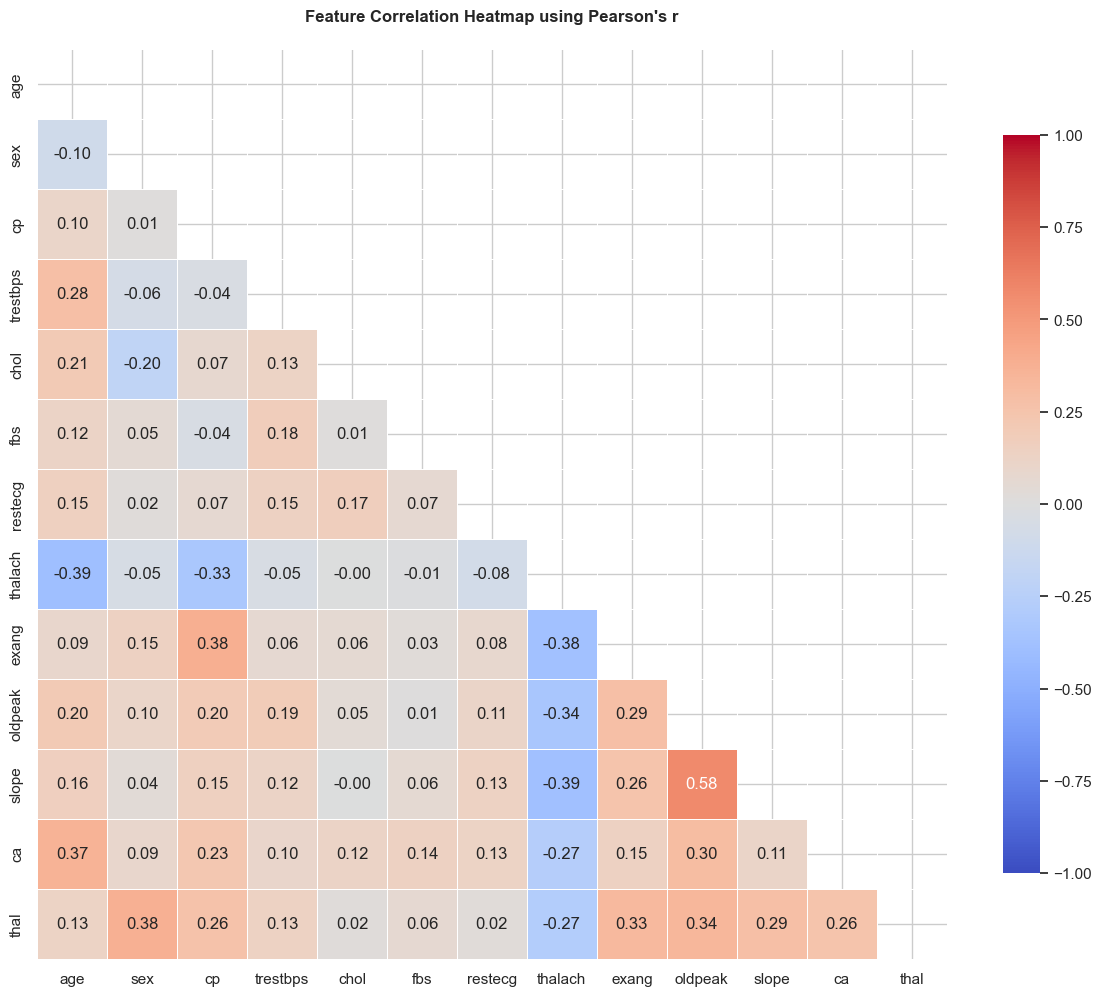

In [13]:
# We calculate the correlation matrix for the continuous variables (using Pearson correlation)
corr_pearson = data.corr(method="pearson")  

# Show only lower triangle (cleaner)
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_pearson,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Heatmap using Pearson's r", fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

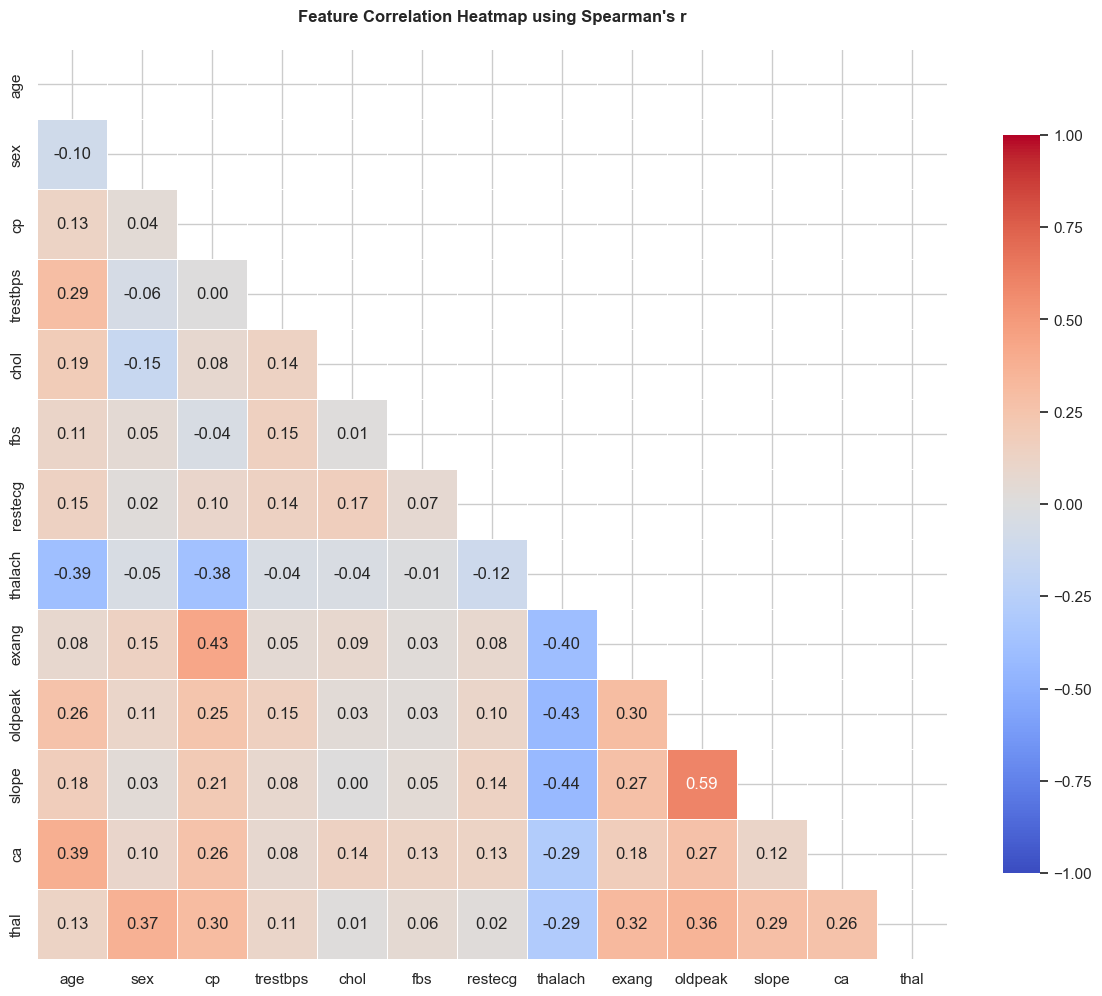

In [14]:
# We calculate the correlation matrix for the continuous variables (using Spearman correlation)
corr_spearman = data.corr(method="spearman")  

# Show only lower triangle (cleaner)
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_spearman,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Heatmap using Spearman's r", fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

We can observe that using Pearson's or Spearman's r leads to very similar feature correlation heatmaps; thus, we will discuss Pearson's approach. For simplicity, we only show the lower triangle to obtain a cleaner visualization and avoid redundancy.

Most features exhibit weak to moderate correlations (|r| < 0.4), which suggests limited collinearity within the dataset. However, we observe a stronger positive relationship (r ≈ 0.58) between the Slope of Peak ST Segment (slope) and ST depression (oldpeak). Both variables describe ST-segment dynamics recorded during ECG, therefore some physiological relationship is expected. Finally, Maximum Heart Rate Achieved (thalach) also shows moderately negative correlations, especially with age and slope, which is consistent with lower maximum heart rate in older or more symptomatic patients.

## **TASK 2**

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

In [16]:
# In this step we binarize the target column: we keep 0, but set anything >0 to 1
y = pd.DataFrame((y['num'] > 0).astype(int), columns=['num'])
print(y.head())

   num
0    0
1    1
2    1
3    0
4    0


### Encoding categorical features (One-hot encoding)

In [17]:
# We encode the features before applying standardization and PCA
data = X_clean.copy()

binary_cols = ["sex", "fbs", "exang"]  # keep as binary, convert to boolean
data[binary_cols] = data[binary_cols].eq(1)

# Target to boolean (works whether y is 0/1 or 0..4)
y_bool = (y["num"] if isinstance(y, pd.DataFrame) else y).gt(0)

nominal_cols = ["cp", "restecg", "slope", "ca", "thal"]  # one-hot encoding
# Drop first category to avoid multicollinearity
X_encoded = pd.get_dummies(data, columns=nominal_cols, drop_first=True, dtype=bool)

print("Original shape:", data.shape)
print("Encoded shape :", X_encoded.shape)
X_encoded.head()


Original shape: (303, 13)
Encoded shape : (303, 20)


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,cp_2,cp_3,cp_4,restecg_1,restecg_2,slope_2,slope_3,ca_1.0,ca_2.0,ca_3.0,thal_6.0,thal_7.0
0,63,True,145,233,True,150,False,2.3,False,False,False,False,True,False,True,False,False,False,True,False
1,67,True,160,286,False,108,True,1.5,False,False,True,False,True,True,False,False,False,True,False,False
2,67,True,120,229,False,129,True,2.6,False,False,True,False,True,True,False,False,True,False,False,True
3,37,True,130,250,False,187,False,3.5,False,True,False,False,False,False,True,False,False,False,False,False
4,41,False,130,204,False,172,False,1.4,True,False,False,False,True,False,False,False,False,False,False,False


As our machine learning models work with numerical inputs, we applied one-hot encoding to the dataset in order to binarize the nominal categorical variables (cp, restecg, slope, ca and thal). We decided not to use label encoding due to the possible introduction of an artificial numerical order between categories that may not have an ordinal relationship. However, variables that were already binary were kept unchanged. Moreover, we used drop_first=True to remove one category from each variable and avoid multicollinearity between the newly generated columns. The dropped category serves as the baseline. The result is a dataset of 303 samples and 20 columns, seven more than before.

### Standardization of our features

In [18]:
# X_encoded = output after get_dummies(...)
X_scaled = X_encoded.copy()

# Standardize only continuous columns
scaler = StandardScaler()
X_scaled[continuous_cols] = scaler.fit_transform(X_scaled[continuous_cols])

# Here we print the original encoded dataset and the standardized dataset, along with the columns that were standardized and those that were kept as binary 0/1.
print("Original columns:")
print(X_encoded)


Original columns:
     age    sex  trestbps  chol    fbs  thalach  exang  oldpeak   cp_2   cp_3  \
0     63   True       145   233   True      150  False      2.3  False  False   
1     67   True       160   286  False      108   True      1.5  False  False   
2     67   True       120   229  False      129   True      2.6  False  False   
3     37   True       130   250  False      187  False      3.5  False   True   
4     41  False       130   204  False      172  False      1.4   True  False   
..   ...    ...       ...   ...    ...      ...    ...      ...    ...    ...   
298   45   True       110   264  False      132  False      1.2  False  False   
299   68   True       144   193   True      141  False      3.4  False  False   
300   57   True       130   131  False      115   True      1.2  False  False   
301   57  False       130   236  False      174  False      0.0   True  False   
302   38   True       138   175  False      173  False      0.0  False   True   

      cp_

In [19]:
print("\nContinuous columns standardized:")
print(X_scaled)


Continuous columns standardized:
          age    sex  trestbps      chol    fbs   thalach  exang   oldpeak  \
0    0.948726   True  0.757525 -0.264900   True  0.017197  False  1.087338   
1    1.392002   True  1.611220  0.760415  False -1.821905   True  0.397182   
2    1.392002   True -0.665300 -0.342283  False -0.902354   True  1.346147   
3   -1.932564   True -0.096170  0.063974  False  1.637359  False  2.122573   
4   -1.489288  False -0.096170 -0.825922  False  0.980537  False  0.310912   
..        ...    ...       ...       ...    ...       ...    ...       ...   
298 -1.046013   True -1.234430  0.334813  False -0.770990  False  0.138373   
299  1.502821   True  0.700612 -1.038723   True -0.376896  False  2.036303   
300  0.283813   True -0.096170 -2.238149  False -1.515388   True  0.138373   
301  0.283813  False -0.096170 -0.206864  False  1.068113  False -0.896862   
302 -1.821745   True  0.359134 -1.386944  False  1.024325  False -0.896862   

      cp_2   cp_3   cp_4  res

In [20]:
# We also print the mean and standard deviation values used for scaling, which are stored in the scaler object after fitting. This gives us insight into how the continuous features were transformed.
print("\nScaler Values:")
print(f'\nMeans of each feature: {scaler.mean_}')
print(f'\nStandard deviations of each feature: {scaler.scale_}')

# We also check that the mean of the standardized columns is close to 0 and the standard deviation is close to 1, which confirms that the standardization was applied correctly.
print("\nMean of each column after scaling (should be close to 0):")
print(X_scaled[continuous_cols].mean())
print("\nStandard deviation of each column after scaling (should be close to 1):")
print(X_scaled[continuous_cols].std())


Scaler Values:

Means of each feature: [ 54.43894389 131.68976898 246.69306931 149.60726073   1.03960396]

Standard deviations of each feature: [ 9.02373483 17.57068124 51.69140647 22.83722455  1.15915747]

Mean of each column after scaling (should be close to 0):
age        -1.465641e-18
trestbps    4.426236e-16
chol        2.345026e-16
thalach    -1.172513e-16
oldpeak     2.345026e-17
dtype: float64

Standard deviation of each column after scaling (should be close to 1):
age         1.001654
trestbps    1.001654
chol        1.001654
thalach     1.001654
oldpeak     1.001654
dtype: float64


Before performing PCA, it is necessary to scale our continuous data within a specific range. Since PCA is variance-based and clustering methods are sensitive to scale, standardization of feature values using the z-score is better suited for this task, as it ensures that variables are centered and have comparable variances. This prevents large numerical ranges from dominating our analyses.

### Step A — PCA:

In [21]:
X = X_scaled.copy()
X_mat = X.to_numpy(dtype=float)

### PCA using NumPy

d = X_mat.shape[0]  # number of samples

# Covariance matrix
S = (1/(d-1)) * X_mat.T @ X_mat
# eigenvalues are the variances of the principal components, eigenvectors are the directions of the principal components
[eigenvalues, eigenvectors] = np.linalg.eig(S) 
# We sort the eigenvalues in descending order and reorder the eigenvectors accordingly
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# We calculate the explained variance ratio for each principal component
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
print("Explained variance ratio of each principal component:")
print(explained_variance_ratio)

# Project the data onto the first 2 principal components
n = 2
W = eigenvectors[:, :n]  # projection matrix using the first n eigenvectors
X_pca_manual = X_mat @ W  # projected data in the PCA space
print("\nShape of PCA-transformed data (manual):", X_pca_manual.shape)

# Cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)
print("\nCumulative explained variance ratio:")
print(cumulative_explained_variance)

# 85% of the variance is explained by the first 2 principal components
print("\nNumber of principal components needed to explain at least 85% of the variance:",
      np.argmax(cumulative_explained_variance >= 0.85) + 1)



Explained variance ratio of each principal component:
[0.25358308 0.17873346 0.12276921 0.09979647 0.08721514 0.05587056
 0.03554753 0.02754284 0.0234115  0.02082637 0.01843937 0.01647457
 0.01436077 0.01240881 0.01000482 0.00809157 0.0054718  0.00473195
 0.00340388 0.00131628]

Shape of PCA-transformed data (manual): (303, 2)

Cumulative explained variance ratio:
[0.25358308 0.43231654 0.55508575 0.65488222 0.74209736 0.79796793
 0.83351545 0.86105829 0.88446979 0.90529616 0.92373553 0.9402101
 0.95457088 0.96697969 0.97698451 0.98507609 0.99054789 0.99527984
 0.99868372 1.        ]

Number of principal components needed to explain at least 85% of the variance: 8


In [22]:
### 2) PCA con scikit-learn
pca = PCA(n_components=20)
X_pca_sklearn = pca.fit_transform(X)

#Explained variance ratio
print("Explained variance ratio of each principal component (sklearn):")
print(pca.explained_variance_ratio_)
print("\nShape of PCA-transformed data (sklearn):", X_pca_sklearn.shape)

# Cumulative explained variance
pca_cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)
print("\nCumulative explained variance ratio:")
print(pca_cumulative_explained_variance)

# 85% of the variance is explained by the first 2 principal components
print("\nNumber of principal components needed to explain at least 85% of the variance:",
      np.argmax(pca_cumulative_explained_variance >= 0.85) + 1)

Explained variance ratio of each principal component (sklearn):
[0.26729601 0.15739247 0.1215409  0.10798331 0.06963363 0.04799615
 0.03486964 0.03261602 0.02825356 0.02517682 0.02235044 0.01881878
 0.01744497 0.01509823 0.01211682 0.00666522 0.0059575  0.00437641
 0.00281508 0.00159804]

Shape of PCA-transformed data (sklearn): (303, 20)

Cumulative explained variance ratio:
[0.26729601 0.42468848 0.54622937 0.65421268 0.72384632 0.77184246
 0.8067121  0.83932812 0.86758168 0.8927585  0.91510894 0.93392772
 0.95137269 0.96647092 0.97858775 0.98525297 0.99121047 0.99558688
 0.99840196 1.        ]

Number of principal components needed to explain at least 85% of the variance: 9


In Step A, we applied PCA using two different approaches: first, we performed a manual implementation with NumPy and matrix multiplication, and then using the scikit-learn library, in order to check that both methods lead to consistent results.

In the manual implementation, we calculated the covariance matrix and obtained the eigenvectors and eigenvalues through its decomposition. This allowed us to compute the proportion of explained variance for each principal component. From these results, we observed that in order to explain at least 85% of the variance, we needed the first 8 principal components [0.25358308 0.17873346 0.12276921 0.09979647 0.08721514 0.05587056 0.03554753 0.02754284]. On the other hand, using scikit-learn, the cumulative explained variance ratio showed that at least 9 principal components are required to explain the same percentage of variance [0.26729601 0.15739247 0.1215409 0.10798331 0.06963363 0.04799615 0.03486964 0.03261602 0.02825356]. Even though both methods present a slight difference in values, they lead to a similar conclusion: the dataset requires several dimensions to preserve most of its information.

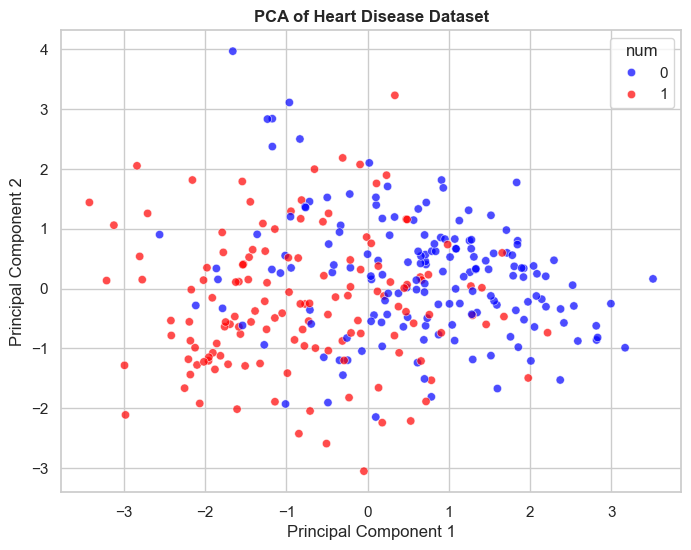

In [23]:
# Plot PCA results
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca_sklearn[:, 0], y=X_pca_sklearn[:, 1], hue=y['num'], palette=["blue", "red"], alpha=0.7)
sns.set_theme(style="whitegrid", context="notebook")
plt.title("PCA of Heart Disease Dataset", fontweight="bold")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

The projection of the data onto the first two principal components allows us to visualize the general structure of the dataset. However, as we can see when using the labels, it does not show a clear separation between the two classes. We can observe some local tendencies: blue dots (healthy) seem to be slightly concentrated on the right side of the plot, while red dots (disease) are more distributed on the left side. However, there is a clear overlap between both groups, which, according to the variance ratio of the first two principal components [0.26729601 0.15739247], confirms that they are not easily separable. Therefore, PCA can be a useful tool for visualization, but two-dimensional projections will not clearly differentiate the observations in a complex dataset.

### Step B — Feature selection:

In [27]:
X_input = X_encoded.copy()   # features
y_input = y_bool.copy()      # boolean target (True/False)

# 1) Split BEFORE the feature selection
X_train, X_test, y_train, y_test = train_test_split(
    X_input,
    y_input,
    test_size=0.20,
    random_state=42,
    stratify=y_input
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (242, 20) Test: (61, 20)


### Fitler method

In [51]:
# Method: Mutual Information
# Type: Filter method
# Nature: Univariate
# Data type: numerical / categorical features with categorical target

k = 8  # number of features to keep

filter_selector = SelectKBest(score_func=mutual_info_classif, k=k)
filter_selector.fit(X_train, y_train)

filter_scores = pd.Series(
    filter_selector.scores_,
    index=X_train.columns
).sort_values(ascending=False)

selected_filter = filter_scores.head(k).index.tolist()

print("Top features (Filter - Mutual Information):")
display(filter_scores.head(k))

Top features (Filter - Mutual Information):


thal_7.0    0.189588
exang       0.106574
slope_2     0.100371
cp_4        0.094721
thalach     0.093405
oldpeak     0.077064
chol        0.069413
ca_3.0      0.068680
dtype: float64

### Wrapper method

In [ ]:
# Method: Recursive Feature Elimination (RFE)
# Type: Wrapper
# Nature: Multivariate

model = LogisticRegression(max_iter=10000, random_state=42)

wrapper_selector = RFE(
    estimator=model,
    n_features_to_select=k
)

wrapper_selector.fit(X_train, y_train)

selected_wrapper = X_train.columns[wrapper_selector.support_].tolist()

print("Selected features (Wrapper - RFE):")
print(selected_wrapper)

Selected features (Wrapper - RFE):
['sex', 'exang', 'cp_4', 'slope_2', 'ca_1.0', 'ca_2.0', 'ca_3.0', 'thal_7.0']


### Overlap

In [53]:
overlap = sorted(set(selected_filter).intersection(selected_wrapper))

print("Filter method features:")
print(selected_filter)

print("\nWrapper method features:")
print(selected_wrapper)

print("\nOverlap between methods:")
print(overlap)

Filter method features:
['thal_7.0', 'exang', 'slope_2', 'cp_4', 'thalach', 'oldpeak', 'chol', 'ca_3.0']

Wrapper method features:
['sex', 'exang', 'cp_4', 'slope_2', 'ca_1.0', 'ca_2.0', 'ca_3.0', 'thal_7.0']

Overlap between methods:
['ca_3.0', 'cp_4', 'exang', 'slope_2', 'thal_7.0']


### Comparison with PCA and final feature subset for clustering

In [56]:
# PCA feature importance based on loadings and explained variance ratio
pc_names = [f"PC{i+1}" for i in range(pca.n_components_)]
loadings = pd.DataFrame(pca.components_.T, index=X_train.columns, columns=pc_names)

weights = pd.Series(pca.explained_variance_ratio_, index=pc_names)
pca_importance = loadings.abs().mul(weights, axis=1).sum(axis=1).sort_values(ascending=False)

# Top features for PCA
k = max(len(selected_filter), len(selected_wrapper))
selected_pca = pca_importance.head(k).index.tolist()

print("Top features por PCA:")
print(selected_pca)

# Comparison of the three methods
comparison = pd.DataFrame({
    "PCA_importance": pca_importance,
    "in_filter": [f in selected_filter for f in pca_importance.index],
    "in_wrapper": [f in selected_wrapper for f in pca_importance.index],
    "in_PCA_top": [f in selected_pca for f in pca_importance.index],
})

# Count how many methods selected each feature
comparison["n_methods"] = (
    comparison[["in_filter", "in_wrapper", "in_PCA_top"]]
    .sum(axis=1)
)

# Feature present in at least two methods
comparison["in_at_least_one"] = comparison["n_methods"] >= 1

comparison = comparison.sort_values("PCA_importance", ascending=False)

display(comparison.head(20))

# Extract features selected by at least two methods
features_one_methods = comparison[comparison["in_at_least_one"]].index.tolist()
n_one_methods = len(features_one_methods)

print("\nFeatures present in at least two methods:", features_one_methods)
print("Number of features present in at least two methods:", n_one_methods)

Top features por PCA:
['thalach', 'oldpeak', 'age', 'trestbps', 'chol', 'cp_4', 'exang', 'thal_7.0']


,PCA_importance,in_filter,in_wrapper,in_PCA_top,n_methods,in_at_least_one
thalach,0.325396,True,False,True,2,True
oldpeak,0.315603,True,False,True,2,True
age,0.304566,False,False,True,1,True
trestbps,0.295121,False,False,True,1,True
chol,0.293689,True,False,True,2,True
cp_4,0.152736,True,True,True,3,True
exang,0.139056,True,True,True,3,True
thal_7.0,0.135734,True,True,True,3,True
slope_2,0.131376,True,True,False,2,True
cp_3,0.110648,False,False,False,0,False



Features present in at least two methods: ['thalach', 'oldpeak', 'age', 'trestbps', 'chol', 'cp_4', 'exang', 'thal_7.0', 'slope_2', 'sex', 'ca_1.0', 'ca_2.0', 'ca_3.0']
Number of features present in at least two methods: 13


The training and test set split were performed as (80 % - 20%). To perform variable selection, we applied two different approaches to the training set: a filter method and a wrapper method. First, we used Mutual Information as a univariate filtering technique to measure the dependency between each variable and the target. This method is model-agnostic and allows us to identify which variables carry more information individually, thus producing a ranking (k = 8) of feature relevance. Afterwards, we applied a wrapper method through Recursive Feature Elimination (RFE) with a logistic regression model, which evaluates the contribution of variables in a multivariate way by considering their combined effect on the model. Finally, we compared these results with the contribution of each variable to the PCA by computing the weighted loadings, obtained by multiplying the absolute loadings by the explained variance ratio of each principal component.

Given that the categorical variables were encoded through one-hot encoding, the generated columns were interpreted as corresponding groups of the same original variable rather than as independent variables. For this reason, the final selection was performed considering the overall relevance of each original variable. We prioritized those variables that appeared in at least two methods and that showed the greatest contribution to the PCA structure. Following this criterion, we retained the variables related to maximum heart rate achieved (thalach), ST depression (oldpeak), chest pain type (cp), exercise-induced angina (exang), slope of the peak ST segment (slope), cholesterol (chol), resting blood pressure (trestbps), age, and the thalassemia indicator (thal). On the other hand, resting ECG results (restecg), fasting blood sugar (fbs), and major vessels (ca) were discarded because they were not selected by any of the methods or showed low importance in the selection criteria, with a limited contribution to the PCA structure. Therefore, we end up with 13 columns.


In [59]:
selected_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "exang",
    "cp_2", "cp_3", "cp_4",
    "slope_2", "slope_3",
    "thal_6.0", "thal_7.0"
]

not_selected_features = [
    "restecg_1", "restecg_2",
    "sex",
    "fbs",
    "ca.1", "ca.2", "ca.3"
]

# Apply selection to train and test sets
X_train_selected = X_train[selected_features].copy()
X_test_selected = X_test[selected_features].copy()

print("Train shape after feature selection:", X_train_selected.shape)
print("Test shape after feature selection:", X_test_selected.shape)

Train shape after feature selection: (242, 13)
Test shape after feature selection: (61, 13)


## **TASK 3**